Analistes de Màrqueting i Comunicació: Quin és l'impacte del tipus de contacte, ja sigui mòbil o
telefònic, a la taxa de conversió de les nostres campanyes de màrqueting, i com podem ajustar
les nostres estratègies de comunicació en funció d'aquests resultats?

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

plt.style.use('seaborn-v0_8')


df = pd.read_csv("/Users/ivansoto/Desktop/UTM/SPRINT2/031125_dataset.csv", sep = ";", encoding = "latin-1")


In [44]:
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000,16162.000000
mean,9696.708514,41.312152,1535.302067,15.671885,370.811533,2.513055,51.420864,0.834241
std,6754.510024,11.927441,3292.261675,8.438361,347.467998,2.736740,109.471445,2.287959
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,4041.250000,32.000000,124.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,8081.500000,39.000000,556.000000,15.000000,254.000000,2.000000,-1.000000,0.000000
75%,17342.750000,49.000000,1708.000000,22.000000,494.000000,3.000000,9.000000,1.000000
max,21383.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [72]:
volumen_por_canal = df['contact'].value_counts()

print(volumen_por_canal)

contact
cellular     11610
unknown       3404
telephone     1148
Name: count, dtype: int64


In [66]:
conversion_por_canal = (
    df.groupby('contact')['deposit']
    .apply(lambda x: (x == 'yes').mean())
)
print(conversion_por_canal)


contact
cellular     0.539966
telephone    0.498258
unknown      0.227086
Name: deposit, dtype: float64


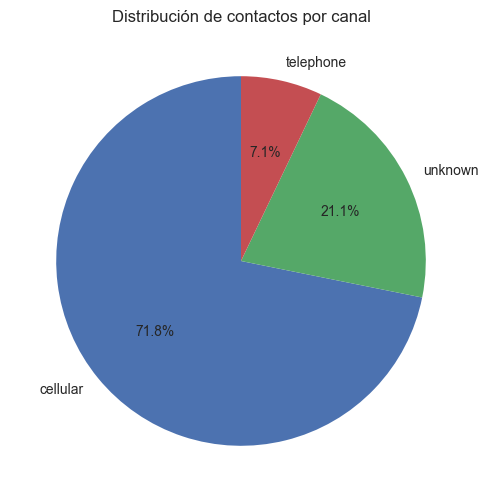

In [46]:
contact_counts = df['contact'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(contact_counts, labels=contact_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de contactos por canal')
plt.show()


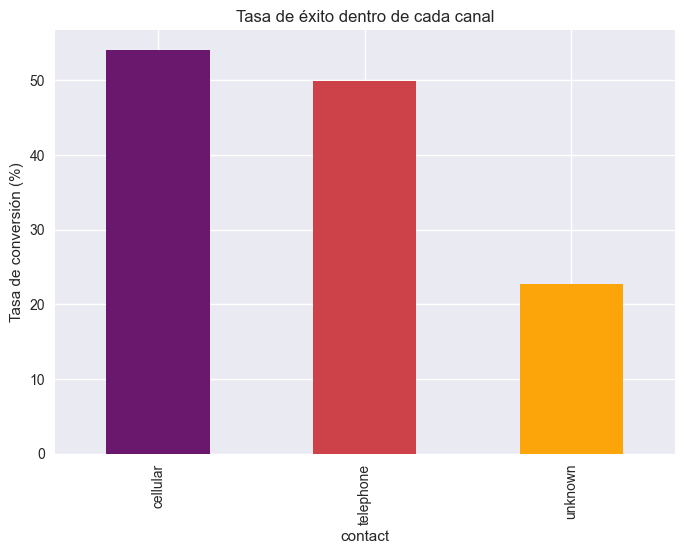

In [47]:
conversion_rate = df.groupby('contact')['deposit'].apply(lambda x: (x == 'yes').mean() * 100)

conversion_rate.plot(kind='bar', color=plt.cm.inferno(np.linspace(0.3, 0.8, len(conversion_rate))))
plt.ylabel('Tasa de conversión (%)')
plt.title('Tasa de éxito dentro de cada canal')
plt.show()


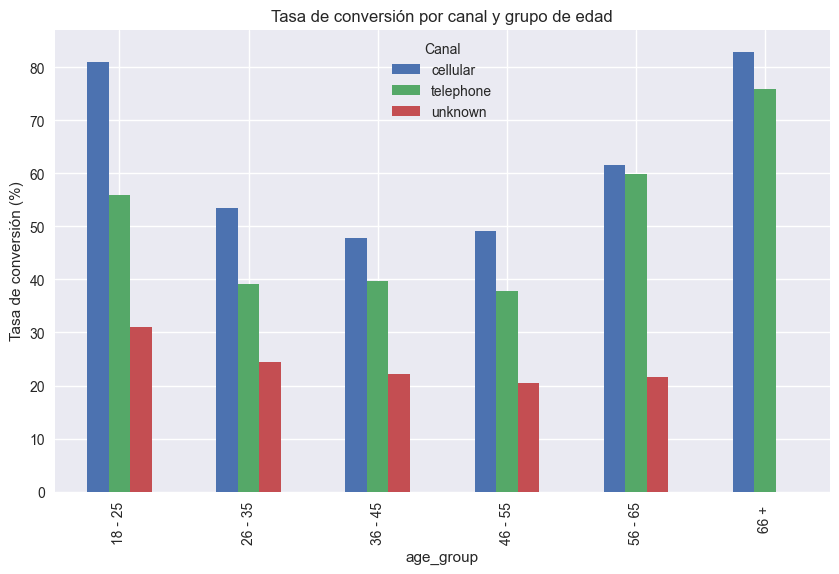

In [53]:
conv_age_channel = df.groupby(['age_group', 'contact'])['deposit'].apply(lambda x: (x == 'yes').mean() * 100).unstack()

conv_age_channel.plot(kind='bar', figsize=(10,6))
plt.title('Tasa de conversión por canal y grupo de edad')
plt.ylabel('Tasa de conversión (%)')
plt.legend(title='Canal')
plt.show()


In [61]:
tasa_exito_pcanal = (exitos_pcanal / total_depositos_xcanal * 100).round(2)


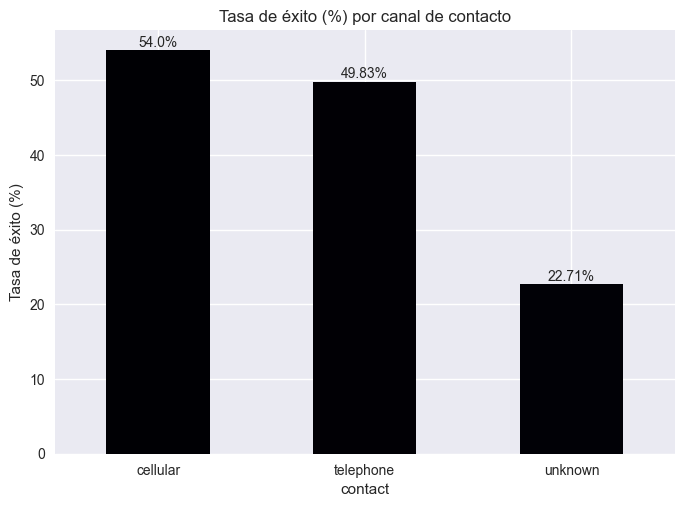

In [50]:
import matplotlib.pyplot as plt

tasa_exito_pcanal.plot(kind='bar', color=plt.cm.inferno(range(len(tasa_exito_pcanal))))

plt.title("Tasa de éxito (%) por canal de contacto")
plt.ylabel("Tasa de éxito (%)")
plt.xticks(rotation=0)

for i, valor in enumerate(tasa_exito_pcanal):
    plt.text(i, valor + 0.5, f"{valor}%", ha='center', fontsize=10)

plt.show()


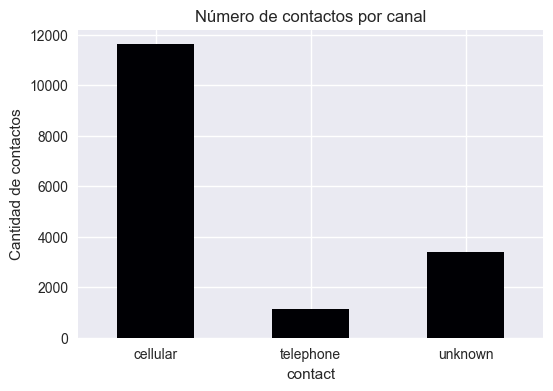

In [51]:
import matplotlib.pyplot as plt


df.groupby('contact')['deposit'].count().plot(
    kind='bar',
    colormap='inferno',
    figsize=(6,4)
)

plt.title("Número de contactos por canal")
plt.xticks(rotation=0)
plt.ylabel("Cantidad de contactos")
plt.show()

In [54]:
contingencia = pd.crosstab(df['contact'], df['deposit'])
chi2, p, dof, expected = chi2_contingency(contingencia)
print(f"Chi-cuadrado: {chi2:.2f}")
print(f"p-valor: {p:.5e}")


Chi-cuadrado: 1037.83
p-valor: 4.34700e-226
